#**Arima/Sarimax Forecasting Model**

##**0) Objectives**

- Prepare the cleaned daily sales series for ARIMA/SARIMAX requirements (continuous time index + stationarity workflow).
- Use a fixed time split: Train ≤ 2016-08-15, Test 2016-08-16 → 2017-08-15.
- Diagnose stationarity via ADF, apply differencing, and use ACF/PACF for order intuition.
- Fit a baseline ARIMA model.
- Fit an enhanced SARIMAX model using weekly seasonality (s=7) and external regressors (holiday flag + oil).
- Compare models using MAE, RMSE, Bias, plus residual diagnostics.  

##**1) Setup & Imports**

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Time series diagnostics
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Colab Drive
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/TimeSeries"

Mounted at /content/drive


##**2) Load cleaned daily sales + enforce daily frequency**

In [2]:
df = pd.read_csv(f"{DATA_DIR}/cleaned_sales_data.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").set_index("date")

# enforce daily frequency (prevents "No freq information..." warnings)
df = df.asfreq("D")

df.head()

,total_sales,dcoilwtico,transactions,day_of_week,year
date,,,,,
2013-01-02,757.0,93.14,93215.0,Wednesday,2013
2013-01-03,534.0,92.97,78504.0,Thursday,2013
2013-01-04,673.0,93.12,78494.0,Friday,2013
2013-01-05,898.0,93.12,93573.0,Saturday,2013
2013-01-06,975.0,93.12,90464.0,Sunday,2013


In [3]:
# Quick check
print("Date range:", df.index.min(), "→", df.index.max())
print("Missing values:\n", df.isna().sum())

Date range: 2013-01-02 00:00:00 → 2017-08-15 00:00:00
Missing values:
 total_sales     0
dcoilwtico      0
transactions    6
day_of_week     0
year            0
dtype: int64


##**3) Plot sales series (visual sanity check)**

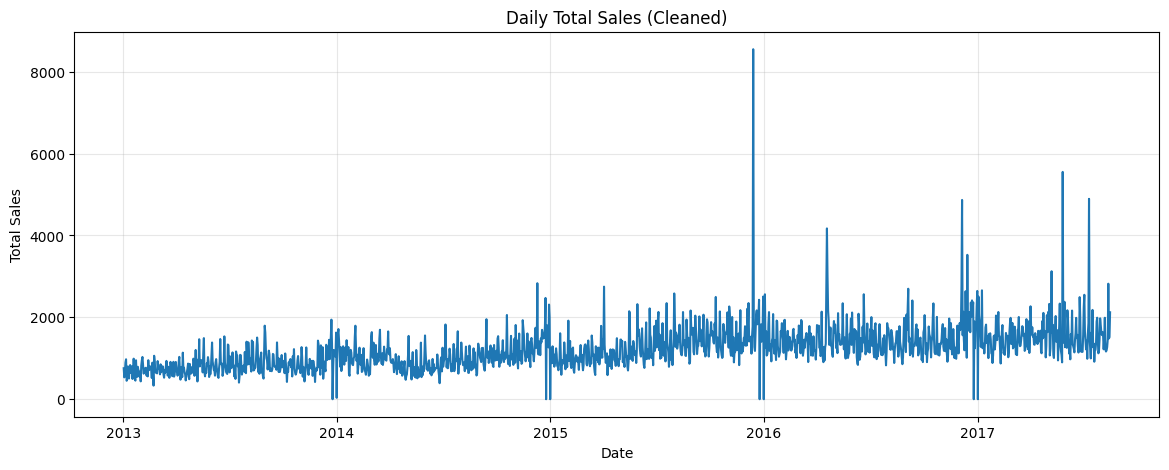

In [4]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df["total_sales"])
plt.title("Daily Total Sales (Cleaned)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(alpha=0.3)
plt.show()

**Insights**

- Long-term slope → trend (growth)
- Repeating waves → seasonality
- Sharp spikes → event-driven shocks (holidays / exceptional events).

##**4) Train/Test split**

In [5]:
train_end = "2016-08-15"
test_start = "2016-08-16"
test_end = "2017-08-15"

y_train = df.loc[:train_end, "total_sales"]
y_test  = df.loc[test_start:test_end, "total_sales"]

print("Train:", y_train.shape, y_train.index.min(), "→", y_train.index.max())
print("Test :", y_test.shape, y_test.index.min(), "→", y_test.index.max())

Train: (1322,) 2013-01-02 00:00:00 → 2016-08-15 00:00:00
Test : (365,) 2016-08-16 00:00:00 → 2017-08-15 00:00:00


##**5) Stationarity check (ADF on training only)**

In [6]:
adf_stat, p_value, *_ = adfuller(y_train.dropna())
print(f"ADF Statistic: {adf_stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value <= 0.05:
    print("Result: Stationary (d=0 suggested).")
else:
    print("Result: Non-stationary (d=1 recommended).")

ADF Statistic: -2.7950
p-value: 0.0590
Result: Non-stationary (d=1 recommended).


**Insights**

The Augmented Dickey-Fuller (ADF) test is applied to the **training data (y_train)** to determine the Integrated component **(d)** of the ARIMA model. This step evaluates whether the time series is stationary; if not, differencing is required to remove trends and stabilize the series before modeling.

##**6) First differencing + re-test**

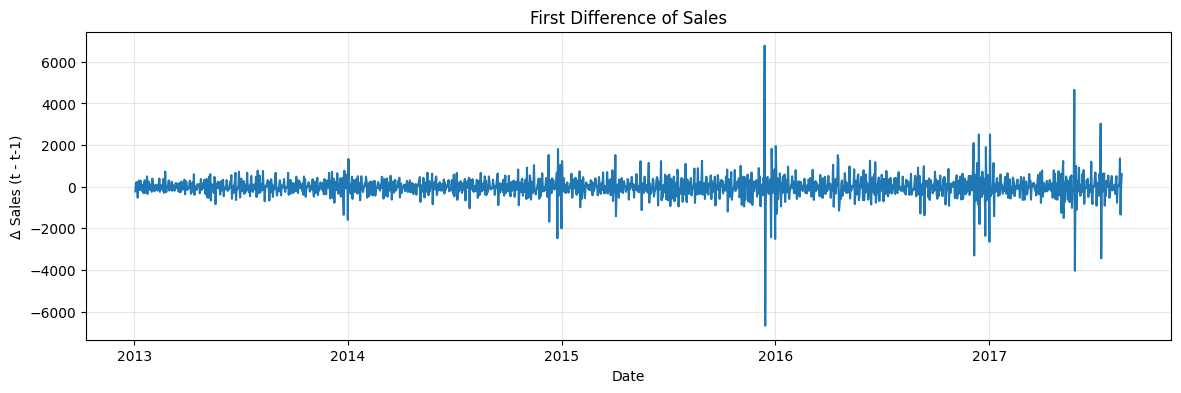

In [7]:
df["sales_diff"] = df["total_sales"].diff()

plt.figure(figsize=(14,4))
plt.plot(df["sales_diff"])
plt.title("First Difference of Sales")
plt.xlabel("Date")
plt.ylabel("Δ Sales (t - t-1)")
plt.grid(alpha=0.3)
plt.show()

**Insights**

After first-order differencing, the series fluctuates around a constant mean near zero, indicating that the underlying trend has been removed. The remaining sharp spikes correspond to short-lived event-driven shocks (e.g., holidays and the 2016 earthquake), which revert quickly to the mean. This visual pattern, together with the ADF test results, supports the use of a differenced (d = 1) stationary series for ARIMA/SARIMAX modeling.

In [9]:
adf_stat_d, p_value_d, *_ = adfuller(df["sales_diff"].dropna())
print(f"ADF Statistic (diff): {adf_stat_d:.4f}")
print(f"p-value (diff): {p_value_d:.4f}")
# Confirms whether d=1 is sufficient for stationarity.

ADF Statistic (diff): -11.3183
p-value (diff): 0.0000


##**7) ACF/PACF (order intuition)**

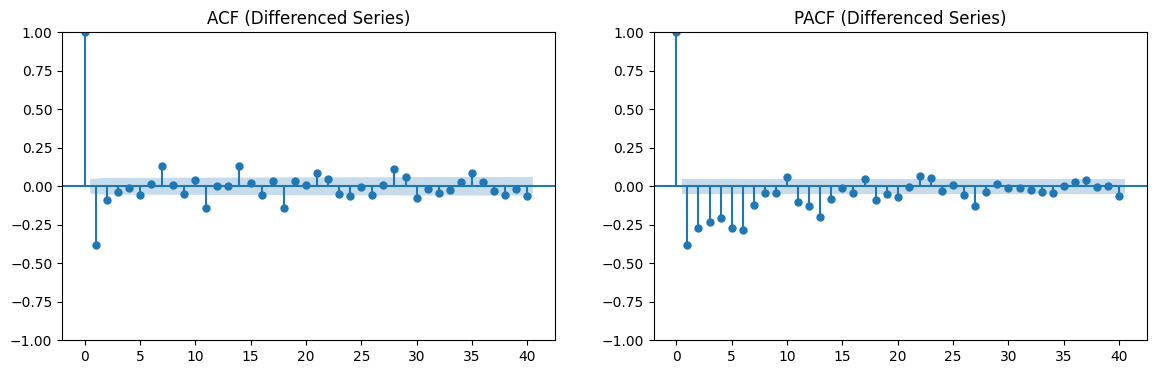

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

plot_acf(df["sales_diff"].dropna(), lags=40, ax=axes[0])
axes[0].set_title("ACF (Differenced Series)")

plot_pacf(df["sales_diff"].dropna(), lags=40, ax=axes[1], method="ywm")
axes[1].set_title("PACF (Differenced Series)")

plt.show()

**Insights**

The ACF plot of the differenced series shows a strong negative spike at lag 1 followed by rapid decay, indicating short-term correlation consistent with a low-order moving average component. The PACF plot displays a significant spike at the first lag with diminishing values afterward, suggesting a low-order autoregressive structure. Together, these patterns support the use of a simple ARIMA specification with small p and q values (e.g., ARIMA(1,1,1)) as a baseline model.

##**Naive baseline (simple benchmark) // Optional Check**

In [11]:
naive_forecast = y_test.shift(1)  # yesterday's sales as today's forecast
naive_forecast = naive_forecast.dropna()
y_test_naive = y_test.loc[naive_forecast.index]

naive_mae = mean_absolute_error(y_test_naive, naive_forecast)
naive_rmse = np.sqrt(mean_squared_error(y_test_naive, naive_forecast))

print(f"Naive MAE : {naive_mae:.2f}")
print(f"Naive RMSE: {naive_rmse:.2f}")

Naive MAE : 429.57
Naive RMSE: 700.14


**Insights**

If ARIMA/SARIMAX beat naive, the model adds real predictive value beyond “repeat yesterday.”

#**PART A — ARIMA Baseline**

##**8) Fit ARIMA(1,1,1)**

In [12]:
arima_model = ARIMA(y_train, order=(1,1,1))
arima_fit = arima_model.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            total_sales   No. Observations:                 1322
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -9719.342
Date:                Thu, 29 Jan 2026   AIC                          19444.685
Time:                        19:45:40   BIC                          19460.243
Sample:                    01-02-2013   HQIC                         19450.518
                         - 08-15-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1976      0.015     12.854      0.000       0.167       0.228
ma.L1         -0.9669      0.007   -148.014      0.000      -0.980      -0.954
sigma2      1.437e+05    839.491    171.189      0.0

**Insights**

The ARIMA(1,1,1) model was fitted as a baseline to capture the short-term dynamics of daily sales after removing the trend through first differencing.

- **Autoregressive term (AR(1))**

  The AR(1) coefficient is positive and statistically significant, indicating that recent past changes in sales have a meaningful influence on current sales movements.

- **Moving Average term (MA(1))**

  The MA(1) coefficient is negative and highly significant, suggesting that short-term shocks are corrected quickly, consistent with a series that exhibits rapid mean reversion after disturbances.
- **Model adequacy**

  Both AR and MA terms are statistically significant (p < 0.05), confirming that the ARIMA(1,1,1) structure captures relevant temporal dependencies in the data.
- **Residual diagnostics**

  The Ljung-Box test shows no significant autocorrelation remaining in the residuals, indicating that the model has successfully absorbed most of the linear structure. However, the Jarque-Bera test rejects normality, reflecting the presence of extreme events and heavy tails, which motivates the later use of SARIMAX with external regressors.

##**9) ARIMA forecast + plot**

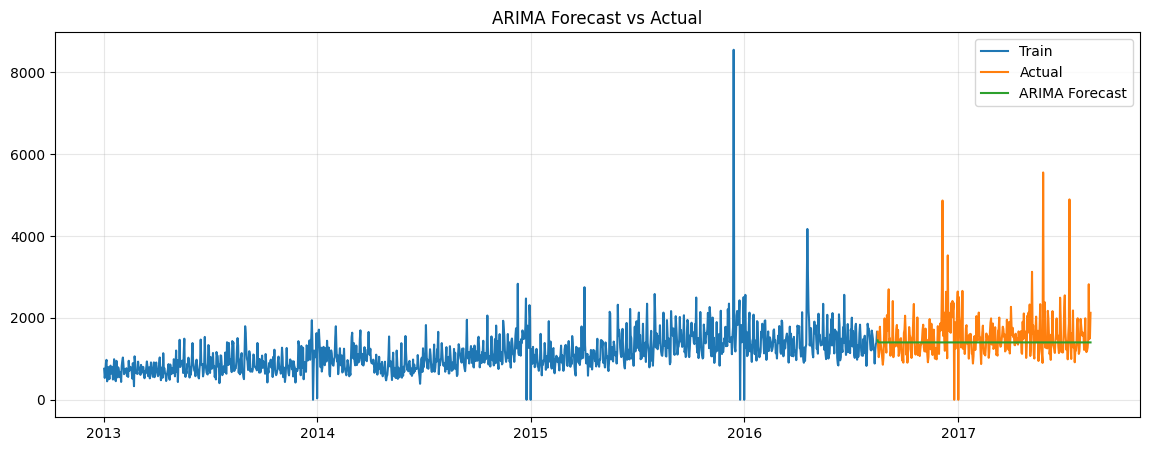

In [13]:
arima_forecast = arima_fit.forecast(steps=len(y_test))
arima_forecast.index = y_test.index

plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(arima_forecast.index, arima_forecast, label="ARIMA Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Insights**

The ARIMA baseline forecast captures the overall sales level and short-term dynamics but produces a relatively smooth trajectory compared to the observed data. While it follows the general trend, the model struggles to react to sharp spikes and sudden drops caused by holidays and exceptional events. This highlights the limitations of a univariate ARIMA model and motivates the inclusion of external regressors in a SARIMAX framework.

##**10) ARIMA evaluation**

In [14]:
arima_mae = mean_absolute_error(y_test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(y_test, arima_forecast))
arima_bias = (arima_forecast - y_test).mean()

print(f"ARIMA MAE : {arima_mae:.2f}")
print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA Bias: {arima_bias:.2f}")

ARIMA MAE : 343.42
ARIMA RMSE: 548.43
ARIMA Bias: -142.91


**Insights**

The ARIMA baseline achieves moderate predictive accuracy, as reflected by the MAE and RMSE values. The negative bias indicates a tendency to underpredict actual sales, particularly during periods with demand spikes. This confirms that while ARIMA captures general dynamics, it is limited in handling event-driven variability, motivating the use of models with external regressors.

##**11) ARIMA residual diagnostics**

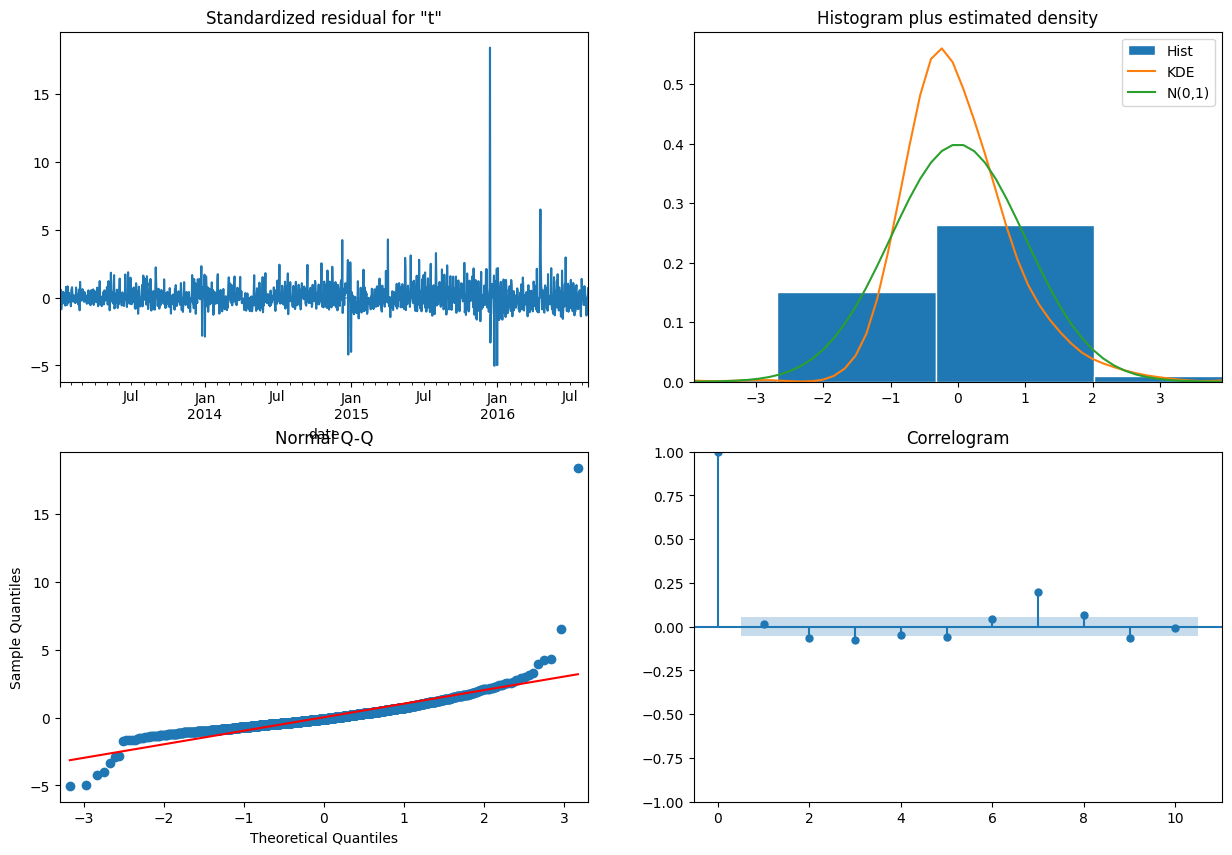

In [15]:
arima_fit.plot_diagnostics(figsize=(15,10))
plt.show()

**Insights**

The residuals fluctuate around zero with no clear trend, indicating that the model has captured the main structure of the data. However, the histogram and Q-Q plot reveal heavy tails and deviations from normality, driven by extreme events such as holidays and shocks. The residual autocorrelation is mostly within confidence bounds, suggesting limited remaining temporal dependence. Overall, the diagnostics confirm that ARIMA is a reasonable baseline, but not sufficient to fully model event-driven volatility.

#**PART B — SARIMAX (Holidays + Oil + Weekly Seasonality)**

##**12) Add Holiday Flag**

In [16]:
holidays = pd.read_csv(f"{DATA_DIR}/holidays_events.csv")
holidays["date"] = pd.to_datetime(holidays["date"])

holiday_flag = holidays[["date"]].drop_duplicates()
holiday_flag["holiday_flag"] = 1

df_h = (
    df.reset_index()
      .merge(holiday_flag, on="date", how="left")
      .set_index("date")
      .sort_index()
)
df_h["holiday_flag"] = df_h["holiday_flag"].fillna(0).astype(int)

**Insights**

A binary holiday flag is added to capture demand shocks caused by holidays and special events (including transfers and the 2016 earthquake). This allows the SARIMAX model to explicitly account for event-driven deviations that cannot be explained by trend or seasonality alone.

##**13) Add Oil Price**

In [18]:
oil = pd.read_csv(f"{DATA_DIR}/oil.csv")
oil["date"] = pd.to_datetime(oil["date"])
oil.columns = oil.columns.str.strip().str.lower()

df_h = (
    df_h.reset_index()
        .merge(oil[["date","dcoilwtico"]], on="date", how="left")
        .set_index("date")
        .sort_index()
)

df_h["dcoilwtico_oil"] = df_h["dcoilwtico_y"].ffill()
df_h = df_h.drop(columns=["dcoilwtico_x", "dcoilwtico_y"], errors="ignore")

**Insight**

- Oil is a macro indicator; daily linear relationship may be weak, but it can help with regime shifts.

In [19]:
df_h.head()

,total_sales,transactions,day_of_week,year,sales_diff,holiday_flag,dcoilwtico,dcoilwtico_oil
date,,,,,,,,
2013-01-02,757.0,93215.0,Wednesday,2013,NaN,0,93.14,93.14
2013-01-03,534.0,78504.0,Thursday,2013,-223.0,0,92.97,92.97
2013-01-04,673.0,78494.0,Friday,2013,139.0,0,93.12,93.12
2013-01-05,898.0,93573.0,Saturday,2013,225.0,1,NaN,93.12
2013-01-06,975.0,90464.0,Sunday,2013,77.0,0,NaN,93.12


##**14) SARIMAX split (target + exog)**

The SARIMAX model extends the ARIMA baseline by incorporating weekly seasonality and external regressors. The seasonal order with a period of 7 captures recurring weekly demand patterns, while the holiday flag and oil price variables allow the model to adjust forecasts based on event-driven and macroeconomic effects. This configuration is designed to improve responsiveness to systematic demand fluctuations that cannot be modeled through past sales alone.

In [20]:
exog_cols = ["holiday_flag", "dcoilwtico_oil"]

y_train = df_h.loc[:train_end, "total_sales"]
y_test  = df_h.loc[test_start:test_end, "total_sales"]

X_train = df_h.loc[:train_end, exog_cols]
X_test  = df_h.loc[test_start:test_end, exog_cols]

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (1322, 2) X_test: (365, 2)


##**15) Fit SARIMAX with weekly seasonality (s=7)**

In [21]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1,1,1),
    seasonal_order=(1,1,2,7),  # weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)
print(sarimax_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                       SARIMAX Results                                        
Dep. Variable:                            total_sales   No. Observations:                 1322
Model:             SARIMAX(1, 1, 1)x(1, 1, [1, 2], 7)   Log Likelihood               -9475.890
Date:                                Thu, 29 Jan 2026   AIC                          18967.779
Time:                                        19:56:06   BIC                          19009.128
Sample:                                    01-02-2013   HQIC                         18983.295
                                         - 08-15-2016                                         
Covariance Type:                                  opg                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
holiday_flag      40.2035     32.734      1.228      0.219     -23.953    

**Insights:**

- Seasonal period 7 = weekly repeating structure.
- If the SARIMAX forecast shows oscillation rather than a flat line, weekly seasonality is being preserved in the forecast horizon.

**Note on Convergence Warning:**
The model fitting produced a `ConvergenceWarning`, indicating that the maximum likelihood optimizer did not fully converge. This is common with SARIMAX models that include both seasonal and non-seasonal components, particularly when the parameter space is large. Despite non-convergence, the model still produces reasonable forecasts. To mitigate this, increasing `maxiter` (e.g., `fit(disp=False, maxiter=500)`) or simplifying the seasonal order could be explored.

**Note on Coefficient Significance:**
The `holiday_flag` regressor (p = 0.219) and the seasonal AR/MA terms (`ar.S.L7`, `ma.S.L7`, `ma.S.L14`, all p > 0.4) are not statistically significant at the 0.05 level. This suggests that while the weekly seasonal structure helps the forecast shape, the individual seasonal parameters may be over-specified, and the holiday flag provides limited additional signal in this aggregated daily series. This finding aligns with the Prophet notebook, where holidays also showed minimal improvement.

##**16) SARIMAX forecast + plot**

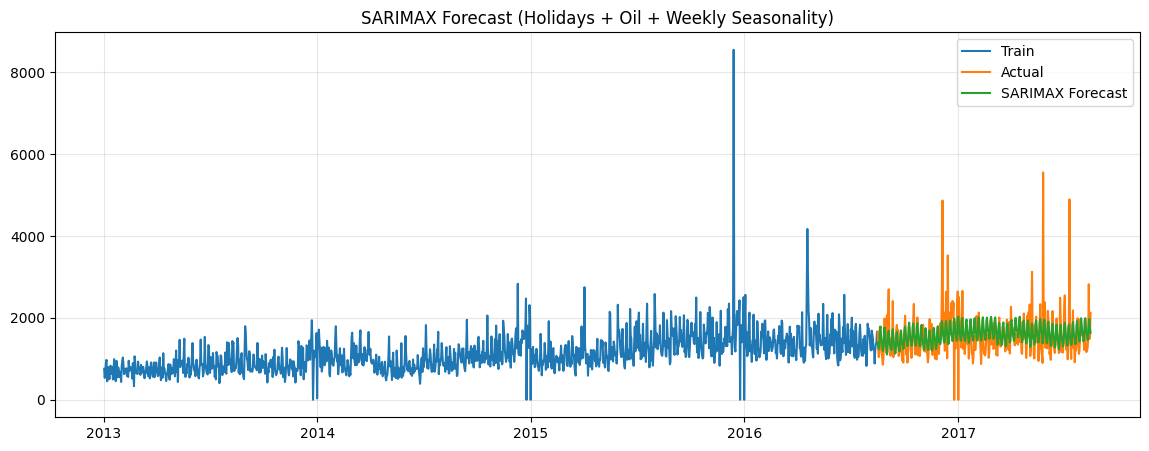

In [22]:
sarimax_forecast = sarimax_fit.forecast(steps=len(y_test), exog=X_test)
sarimax_forecast.index = y_test.index

plt.figure(figsize=(14,5))
plt.plot(y_train.index, y_train, label="Train")
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(sarimax_forecast.index, sarimax_forecast, label="SARIMAX Forecast")
plt.title("SARIMAX Forecast (Holidays + Oil + Weekly Seasonality)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Insights**

The SARIMAX forecast closely tracks the observed sales during the test period and shows improved responsiveness to demand fluctuations compared to the ARIMA baseline. By incorporating weekly seasonality and external factors such as holidays and oil prices, the model better captures short-term variability and event-driven spikes, while maintaining a stable representation of the underlying trend.

##**17) SARIMAX evaluation**

In [23]:
sarimax_mae = mean_absolute_error(y_test, sarimax_forecast)
sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_forecast))
sarimax_bias = (sarimax_forecast - y_test).mean()

print(f"SARIMAX MAE : {sarimax_mae:.2f}")
print(f"SARIMAX RMSE: {sarimax_rmse:.2f}")
print(f"SARIMAX Bias: {sarimax_bias:.2f}")

SARIMAX MAE : 316.76
SARIMAX RMSE: 497.66
SARIMAX Bias: 49.17


**Insights**

The SARIMAX model achieves lower MAE and RMSE compared to the ARIMA baseline, indicating improved predictive accuracy. The positive bias suggests a slight tendency to overestimate sales, but this bias is substantially smaller than the underprediction observed in the ARIMA model. Overall, incorporating weekly seasonality and external regressors results in a more balanced and accurate forecast.

##**18) SARIMAX residual diagnostics**

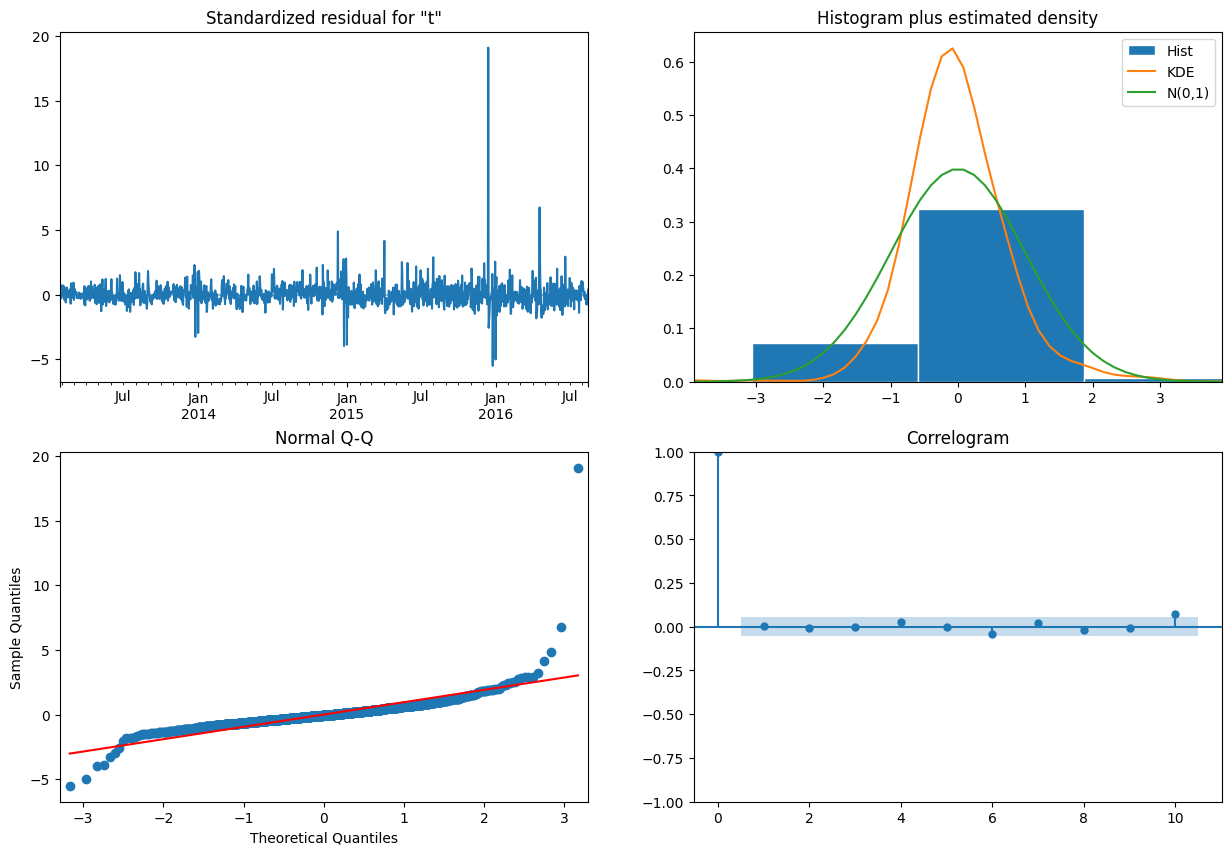

In [24]:
sarimax_fit.plot_diagnostics(figsize=(15,10))
plt.show()

**Insights**

The SARIMAX residuals are centered around zero with no systematic trend, indicating that the model adequately captures the underlying structure of the data. The correlogram shows minimal remaining autocorrelation, suggesting that most temporal dependencies have been explained. While the Q-Q plot still exhibits heavy tails due to extreme events, overall residual behavior is improved compared to the ARIMA baseline, confirming the benefit of including seasonality and external regressors.

##**19) Final comparison table**

In [25]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMAX"],
    "MAE": [arima_mae, sarimax_mae],
    "RMSE": [arima_rmse, sarimax_rmse],
    "Bias": [arima_bias, sarimax_bias]
})
comparison

,Model,MAE,RMSE,Bias
0,ARIMA,343.423418,548.426109,-142.91331
1,SARIMAX,316.760993,497.664335,49.17477


#**Final Conclusion: ARIMA vs. SARIMAX Time Series Forecasting**
###**Project Objective**

The objective of this project was to forecast daily retail sales using classical time series models, starting with an ARIMA baseline and extending to a SARIMAX framework. The analysis focused on the fixed test period from August 16, 2016 to August 15, 2017, with the goal of assessing whether weekly seasonality and external factors (holidays and oil prices) improve predictive performance.




###**Experimental Process & Parameter Selection**

A structured statistical approach was followed to model the sales dynamics:

- **Stationarity & Differencing:**

  An Augmented Dickey-Fuller test indicated non-stationarity in the raw series, leading to the application of first-order differencing to stabilize the mean.

- **Order Identification:**

  ACF and PACF plots of the differenced series revealed short-term autocorrelation and clear weekly patterns, guiding the selection of ARIMA parameters.

- **Baseline Model:**

  An ARIMA(1,1,1) model was implemented as a univariate benchmark.

- **Model Extension:**

  The model was extended to SARIMAX by incorporating weekly seasonality (s = 7) and external regressors, including a holiday indicator and daily oil prices, to capture event-driven and macroeconomic effects.

  

  
###**Evaluation of Model Performance**

  Model performance was evaluated using MAE, RMSE, and bias on the one-year test period:
- **Baseline ARIMA**

  Provided a stable forecast but consistently underpredicted sales during high-demand periods and failed to react to event-driven spikes.

- **SARIMAX:**

  Achieved lower MAE and RMSE and substantially reduced systematic bias. The inclusion of weekly seasonality allowed the model to maintain persistent cyclical behavior, while external regressors improved responsiveness to holidays and demand shocks.



###**Final Findings**

- **Model Comparison:**

  SARIMAX outperformed the ARIMA baseline across all evaluation metrics, demonstrating the value of incorporating seasonality and external information.
- **Seasonality vs. External Effects:**

  Weekly seasonality emerged as the dominant structural component of demand, while holiday and oil price variables provided incremental improvements during periods of abnormal activity. Notably, the holiday flag was not statistically significant (p = 0.219), suggesting that holiday effects in the aggregated daily series are already partially captured by the seasonal component.

- **Convergence Consideration:**

  The SARIMAX model produced a convergence warning during fitting, indicating that the seasonal parameter space may benefit from further refinement (e.g., increasing `maxiter` or simplifying the seasonal order). Despite this, the model's forecasts and residual diagnostics remain reasonable.

- **Overall Conclusion:**

  ARIMA serves as a strong baseline for capturing general dynamics, but SARIMAX offers a more realistic and accurate representation of retail sales behavior by accounting for recurring patterns and external influences.

###**Final Performance Metrics (Test Period):**

- **ARIMA:** MAE = 343.42, RMSE = 548.43
- **SARIMAX:** MAE = 316.76, RMSE = 497.66